# Census-Based Policy Planning: Demographic Analysis for Local Infrastructure Investment

#### Author: Greatness Okeremeta

## Summary

This project analyses a mock census dataset for an imaginary UK town and converts raw demographic records into evidence-based local policy recommendations. The analysis supports two decisions:

1. **Land-use decision:** what should be built on an unoccupied plot of land?
2. **Investment decision:** which public service area should receive additional investment?

## Setup

This section imports the required libraries, configures reusable paths and creates output folders.

In [1]:
# Import Path to build file and folder paths 
from pathlib import Path

# Import warnings to suppress non-critical warning messages
import warnings

# data analysis
import numpy as np
import pandas as pd

# data visualistion
import matplotlib.pyplot as plt
import seaborn as sns

# Import the chi-square test function from SciPy
try:
    from scipy.stats import chi2_contingency
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

# Suppress warning messages 
warnings.filterwarnings("ignore")

# Show up to 100 rows and columns when displaying pandas dataframes
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [2]:
# Project paths

# root folder
PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "summary_tables"
REPORTS_DIR = PROJECT_ROOT / "reports"

# create folders for outputs and reports
for directory in [DATA_RAW_DIR, DATA_PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# print(f"Project root: {PROJECT_ROOT}")
# print(f"Figures will be saved to: {FIGURES_DIR}")

## Load Data

In [3]:
def load_census_data() -> pd.DataFrame:
    """A function to load the census dataset from the portfolio path."""
    data_path = DATA_RAW_DIR / "mock_census.csv"

    if data_path.exists():
        print("Loaded data from data_path!")
        return pd.read_csv(data_path)

    raise FileNotFoundError("Could not find the dataset!")

raw_df = load_census_data()
raw_df.head()

Loaded data from data_path!


,House Number,Street,First Name,Surname,Age,Relationship to Head of House,Marital Status,Gender,Occupation,Infirmity,Religion
0,1,Marsh Turnpike,Megan,Bibi,42,Head,Divorced,Female,Retail merchandiser,NaN,NaN
1,1,Marsh Turnpike,Callum,Bibi,4,Adopted Son,NaN,Male,Child,NaN,NaN
2,2,Marsh Turnpike,Leslie,Stephenson,52,Head,Married,Male,"Research officer, political party",NaN,Christian
3,2,Marsh Turnpike,Katie,Stephenson,53,Wife,Married,Female,Unemployed,NaN,NaN
4,3,Marsh Turnpike,Valerie,Houghton,37,Head,Married,Female,Magazine journalist,NaN,Christian


## Initial Audit

The mock census contains household, demographic, occupation, infirmity and religion data. The audit below checks shape, missingness, duplicated rows, data types, blank strings and core validity issues before cleaning.

In [4]:
EXPECTED_COLUMNS = [
    "House Number",
    "Street",
    "First Name",
    "Surname",
    "Age",
    "Relationship to Head of House",
    "Marital Status",
    "Gender",
    "Occupation",
    "Infirmity",
    "Religion"]

# create a data dictionary describing the dataset features and their expected use
DATA_DICTIONARY = pd.DataFrame({
    "field": EXPECTED_COLUMNS,
    "description": [
        "House or street number within a street",
        "Street name",
        "Occupant first name",
        "Occupant surname",
        "Occupant age",
        "Relationship to the household head",
        "Marital status",
        "Recorded gender",
        "Occupation or economic status",
        "Recorded infirmity, where provided",
        "Recorded religion, where provided"],
    
    "expected_use": [
        "Household identifier component",
        "Household identifier component",
        "Record completeness only; not used for policy modelling",
        "Record completeness only; not used for policy modelling",
        "Demographic segmentation, ageing, schooling, working-age analysis",
        "Household structure analysis",
        "Marriage/divorce and housing demand proxy",
        "Demographic segmentation",
        "Employment, student, commuter and affluence proxy analysis",
        "Medical service pressure proxy",
        "Religious facility demand proxy"]
})

DATA_DICTIONARY

,field,description,expected_use
0,House Number,House or street number within a street,Household identifier component
1,Street,Street name,Household identifier component
2,First Name,Occupant first name,Record completeness only; not used for policy ...
3,Surname,Occupant surname,Record completeness only; not used for policy ...
4,Age,Occupant age,"Demographic segmentation, ageing, schooling, w..."
5,Relationship to Head of House,Relationship to the household head,Household structure analysis
6,Marital Status,Marital status,Marriage/divorce and housing demand proxy
7,Gender,Recorded gender,Demographic segmentation
8,Occupation,Occupation or economic status,"Employment, student, commuter and affluence pr..."
9,Infirmity,"Recorded infirmity, where provided",Medical service pressure proxy


In [5]:
def audit_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """A function to return a compact data audit for each column."""
    
    audit = pd.DataFrame({
        "column": df.columns,
        "dtype": [df[col].dtype for col in df.columns],
        "non_null": [df[col].notna().sum() for col in df.columns],
        "missing": [df[col].isna().sum() for col in df.columns],
        "missing_pct": [round(df[col].isna().mean() * 100, 2) for col in df.columns],
        "blank_strings": [df[col].astype(str).str.strip().eq("").sum() if df[col].dtype == "object" else 0 for col in df.columns],
        "unique_values": [df[col].nunique(dropna=True) for col in df.columns]})
    
    return audit
    
# apply the function of the raw dataset
initial_audit = audit_dataframe(raw_df)

# save the audit result as a CSV file
initial_audit.to_csv(TABLES_DIR / "initial_data_quality_audit.csv", index=False)

# preview the audit result
initial_audit

,column,dtype,non_null,missing,missing_pct,blank_strings,unique_values
0,House Number,int64,8485,0,0.00,0,187
1,Street,object,8485,0,0.00,0,104
2,First Name,object,8485,0,0.00,1,368
3,Surname,object,8485,0,0.00,0,641
4,Age,object,8485,0,0.00,1,110
5,Relationship to Head of House,object,7836,649,7.65,1,19
6,Marital Status,object,6420,2065,24.34,0,8
7,Gender,object,8485,0,0.00,0,8
8,Occupation,object,8485,0,0.00,1,1076
9,Infirmity,object,71,8414,99.16,9,7


In [6]:
# print the dataset's stats
print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]:,}")
print(f"Duplicate rows: {raw_df.duplicated().sum():,}")

# check for missing or extra columns
missing_expected = sorted(set(EXPECTED_COLUMNS) - set(raw_df.columns))
extra_columns = sorted(set(raw_df.columns) - set(EXPECTED_COLUMNS))

print(f"Missing expected columns: {missing_expected if missing_expected else 'None'}")
print(f"Extra columns: {extra_columns if extra_columns else 'None'}")

Rows: 8,485
Columns: 11
Duplicate rows: 0
Missing expected columns: None
Extra columns: None


## Cleaning Methodology

- Standardise column names to `snake_case`.
- Strip whitespace from text fields and convert blank strings to missing values.
- Convert age to numeric and flag implausible values.
- Avoid fabricating personal identifiers. Missing names are marked as `Unknown` and flagged.
- Treat missing religion as `Not stated` rather than imputing belief.
- Treat missing infirmity as `None recorded`, this is a census-response limitation.
- Derive household IDs from house number and street.
- Create analytical features for age groups, working-age population, school-age population, retirement-age population, unemployment, commuting and household occupancy.

In [7]:
#check for unique values in select columns

# gender
print(f'Unique Gender values:', raw_df['Gender'].unique())

# marital status
print(f'Unique Marital Status values:', raw_df['Marital Status'].unique())

# religion
print(f'Unique Religion values:', raw_df['Religion'].unique())

Unique Gender values: ['Female' 'Male' 'male' 'M' 'm' 'female' 'f' 'F']
Unique Marital Status values: ['Divorced' nan 'Married' 'Single' 'Widowed' 'W' 'S' 'D' 'M']
Unique Religion values: [nan 'Christian' 'Catholic' 'Methodist' 'Muslim' 'Jewish' 'Sikh' 'Private'
 'Nope' 'Buddist' 'Orthodoxy' 'Jedi' 'Hindu' 'Pagan']


The gender and marital status values have to be standardised for uniformity.

In [8]:
def to_snake_case(column_name: str) -> str:
   
    """A function to convert a column name to snake_case."""
    
    return (
        column_name.strip()
        .lower()
        .replace("/", "_")
        .replace("-", "_")
        .replace(" ", "_"))

In [9]:
# Core cleaning function
def clean_census_core(df: pd.DataFrame) -> pd.DataFrame:
    """
    A function to clean the raw census data. It handles column name standardisation,
    text cleaning, age validation and imputation and missing-value flags for sensitive or important fields.
    """
    cleaned = df.copy()

    # Standardise column names
    cleaned.columns = [to_snake_case(col) for col in cleaned.columns]

    # Standardise text columns: strip whitespace and convert blanks to NaN
    text_cols = cleaned.select_dtypes(include="object").columns

    for col in text_cols:
        cleaned[col] = cleaned[col].astype(str).str.strip()
        cleaned[col] = cleaned[col].replace({
            "": np.nan,
            "nan": np.nan,
            "None": np.nan})

    # Standardise gender values to Female and Male only
    if "gender" in cleaned.columns:
        cleaned["gender"] = cleaned["gender"].replace({
            "Female": "Female",
            "female": "Female",
            "F": "Female",
            "f": "Female",
            "Male": "Male",
            "male": "Male",
            "M": "Male",
            "m": "Male"})

    # Standardise marital status values
    if "marital_status" in cleaned.columns:
        cleaned["marital_status"] = cleaned["marital_status"].replace({
            "S": "Single",
            "M": "Married",
            "D": "Divorced",
            "W": "Widowed",
            "Single": "Single",
            "Married": "Married",
            "Divorced": "Divorced",
            "Widowed": "Widowed"})

    # Rename long column for readability
    cleaned = cleaned.rename(columns={"relationship_to_head_of_house": "relationship_to_head"})

    # Convert age to numeric and flag invalid values
    cleaned["age_raw"] = cleaned["age"]
    cleaned["age"] = pd.to_numeric(cleaned["age"], errors="coerce")

    cleaned["age_invalid_flag"] = (
        cleaned["age"].isna()
        | (cleaned["age"] < 0)
        | (cleaned["age"] > 115))

    cleaned.loc[cleaned["age_invalid_flag"], "age"] = np.nan

    # Impute missing/invalid ages using occupation and gender median, then overall median
    age_medians = cleaned.groupby(["occupation", "gender"], dropna=False)["age"].transform("median")

    cleaned["age_imputed_flag"] = cleaned["age"].isna()
    cleaned["age"] = (
        cleaned["age"]
        .fillna(age_medians)
        .fillna(cleaned["age"].median())
        .round()
        .astype(int))

    # Personal identifiers: do not fabricate names, mark and flag them
    for name_col in ["first_name", "surname"]:
        if name_col in cleaned.columns:
            cleaned[f"{name_col}_missing_flag"] = cleaned[name_col].isna()
            cleaned[name_col] = cleaned[name_col].fillna("Unknown")

    # Relationship to head: avoid over-imputation
    if "relationship_to_head" in cleaned.columns:
        cleaned["relationship_missing_flag"] = cleaned["relationship_to_head"].isna()
        cleaned["relationship_to_head"] = cleaned["relationship_to_head"].fillna("Unknown")

    # Marital status: minors are N/A, adult missing values are unknown
    if "marital_status" in cleaned.columns:
        cleaned["marital_status_missing_flag"] = cleaned["marital_status"].isna()
        cleaned.loc[
            (cleaned["age"] < 16) & (cleaned["marital_status"].isna()),
            "marital_status"] = "N/A"
        cleaned["marital_status"] = cleaned["marital_status"].fillna("Unknown")

    # Religion: missing religion should not be imputed
    if "religion" in cleaned.columns:
        cleaned["religion_missing_flag"] = cleaned["religion"].isna()
        cleaned["religion"] = cleaned["religion"].fillna("Not stated")

    # Infirmity: missing is treated as no recorded infirmity
    if "infirmity" in cleaned.columns:
        cleaned["infirmity_missing_flag"] = cleaned["infirmity"].isna()
        cleaned["infirmity"] = cleaned["infirmity"].fillna("None recorded")

    return cleaned

In [10]:
# Feature engineering function
def add_census_features(cleaned: pd.DataFrame) -> pd.DataFrame:
    """
    A function to add analytical features for demographic, household, employment, commuting, housing-demand and public-service analysis.
    The engineered features support the final land-use and investment decision matrices
    """
    cleaned = cleaned.copy()

    # Household identifier
    cleaned["household_id"] = (
        cleaned["house_number"].astype(str).str.strip()
        + "_"
        + cleaned["street"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_"))

    # Age groups
    age_bins = [0, 4, 10, 15, 18, 24, 34, 44, 54, 64, 74, 84, np.inf]

    age_labels = ["0-4", "5-10", "11-15", "16-18", "19-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75-84","85+"]

    cleaned["age_group"] = pd.cut(
        cleaned["age"],
        bins=age_bins,
        labels=age_labels,
        right=True,
        include_lowest=True)

    # Life-stage indicators
    cleaned["is_child"] = cleaned["age"] < 16
    cleaned["is_school_age"] = cleaned["age"].between(5, 18, inclusive="both")
    cleaned["is_working_age"] = cleaned["age"].between(16, 64, inclusive="both")
    cleaned["is_retirement_age"] = cleaned["age"] >= 65
    cleaned["is_older_elderly"] = cleaned["age"] >= 80
    cleaned["is_under_5"] = cleaned["age"] <= 4
    
    # Used as a simple recent-birth proxy because direct birth records are unavailable
    cleaned["is_age_0_to_1"] = cleaned["age"] <= 1

    # Occupation-based indicators
    occupation = cleaned["occupation"].fillna("").str.lower()

    cleaned["is_unemployed"] = occupation.str.contains("unemployed", case=False, na=False)
    cleaned["is_student"] = occupation.str.contains("student", case=False, na=False)
    cleaned["is_university_student"] = occupation.str.contains("university student", case=False, na=False)

    # Commuter proxy
    commuter_keywords = ["university student", "consultant", "engineer", "developer", "analyst", "manager", "lecturer",
                         "research", "scientist", "accountant", "solicitor","broker", "architect"]


    cleaned["is_commuter_proxy"] = occupation.map(lambda value: any(keyword in value for keyword in commuter_keywords))

    # Professional/affluence proxy
    professional_keywords = ["manager", "director", "engineer", "doctor", "solicitor", "lawyer", "accountant", "consultant", "architect",
                             "scientist", "analyst", "developer", "surgeon", "pharmacist", "lecturer", "research","broker", "executive"]

    cleaned["is_professional_proxy"] = occupation.map(lambda value: any(keyword in value for keyword in professional_keywords))

    # Household size and occupancy bands
    cleaned["household_size"] = cleaned.groupby("household_id")["household_id"].transform("size")

    cleaned["occupancy_band"] = pd.cut(
        cleaned["household_size"],
        bins=[0, 1, 2, 4, np.inf],
        labels=[
            "Single-person",
            "Two-person",
            "Medium household",
            "Large household"])

    return cleaned

In [11]:
# Applying both functions to the raw and cleaned datasets
cleaned_df = clean_census_core(raw_df)
cleaned_df = add_census_features(cleaned_df)

cleaned_df.head()

,house_number,street,first_name,surname,age,relationship_to_head,marital_status,gender,occupation,infirmity,religion,age_raw,age_invalid_flag,age_imputed_flag,first_name_missing_flag,surname_missing_flag,relationship_missing_flag,marital_status_missing_flag,religion_missing_flag,infirmity_missing_flag,household_id,age_group,is_child,is_school_age,is_working_age,is_retirement_age,is_older_elderly,is_under_5,is_age_0_to_1,is_unemployed,is_student,is_university_student,is_commuter_proxy,is_professional_proxy,household_size,occupancy_band
0,1,Marsh Turnpike,Megan,Bibi,42,Head,Divorced,Female,Retail merchandiser,None recorded,Not stated,42,False,False,False,False,False,False,True,True,1_marsh_turnpike,35-44,False,False,True,False,False,False,False,False,False,False,False,False,2,Two-person
1,1,Marsh Turnpike,Callum,Bibi,4,Adopted Son,N/A,Male,Child,None recorded,Not stated,4,False,False,False,False,False,True,True,True,1_marsh_turnpike,0-4,True,False,False,False,False,True,False,False,False,False,False,False,2,Two-person
2,2,Marsh Turnpike,Leslie,Stephenson,52,Head,Married,Male,"Research officer, political party",None recorded,Christian,52,False,False,False,False,False,False,False,True,2_marsh_turnpike,45-54,False,False,True,False,False,False,False,False,False,False,True,True,2,Two-person
3,2,Marsh Turnpike,Katie,Stephenson,53,Wife,Married,Female,Unemployed,None recorded,Not stated,53,False,False,False,False,False,False,True,True,2_marsh_turnpike,45-54,False,False,True,False,False,False,False,True,False,False,False,False,2,Two-person
4,3,Marsh Turnpike,Valerie,Houghton,37,Head,Married,Female,Magazine journalist,None recorded,Christian,37,False,False,False,False,False,False,False,True,3_marsh_turnpike,35-44,False,False,True,False,False,False,False,False,False,False,False,False,4,Medium household


In [12]:
required_features = [
    "household_id",
    "age_group",
    "is_child",
    "is_school_age",
    "is_working_age",
    "is_retirement_age",
    "is_older_elderly",
    "is_under_5",
    "is_age_0_to_1",
    "is_unemployed",
    "is_student",
    "is_university_student",
    "is_commuter_proxy",
    "is_professional_proxy",
    "household_size",
    "occupancy_band"]

missing_features = [col for col in required_features if col not in cleaned_df.columns]

assert not missing_features, f"Missing engineered features: {missing_features}"
assert cleaned_df["age"].between(0, 115).all(), "Age contains invalid values"
assert cleaned_df["household_id"].notna().all(), "Household ID contains missing values"
assert cleaned_df["household_size"].ge(1).all(), "Household size contains invalid values"

print("Feature validation passed.")

Feature validation passed.


## Post-Cleaning Audit and Summary

This section confirms that the cleaned data is suitable for analysis and records the cleaning choices in a summary table.

In [13]:
post_clean_audit = audit_dataframe(cleaned_df)
post_clean_audit.to_csv(TABLES_DIR / "post_clean_data_quality_audit.csv", index=False)
post_clean_audit

,column,dtype,non_null,missing,missing_pct,blank_strings,unique_values
0,house_number,int64,8485,0,0.00,0,187
1,street,object,8485,0,0.00,0,104
2,first_name,object,8485,0,0.00,0,366
3,surname,object,8485,0,0.00,0,641
4,age,int64,8485,0,0.00,0,106
5,relationship_to_head,object,8485,0,0.00,0,19
6,marital_status,object,8485,0,0.00,0,6
7,gender,object,8485,0,0.00,0,2
8,occupation,object,8484,1,0.01,0,1075
9,infirmity,object,8485,0,0.00,0,7


In [14]:
# Summary of the data cleaning actions compiled in a dataframe
data_quality_summary = pd.DataFrame([
    {
        "issue": "Column names not analysis-friendly",
        "action": "Standardised all columns to snake_case",
        "rationale": "Improves readability and makes downstream code easier to maintain"
    },
    {
        "issue": "Age stored as non-numeric / potentially invalid",
        "action": "Converted age to numeric, flagged invalid ages, imputed with occupation-gender median fallback",
        "rationale": "Age is central to population, schooling, workforce and old-age care analysis"
    },
    {
        "issue": "Blank or missing personal names",
        "action": "Flagged missing values and filled with 'Unknown'",
        "rationale": "Avoids fabricating personal identifiers while preserving row-level completeness"
    },
    {
        "issue": "Missing religion",
        "action": "Filled as 'Not stated' and retained a missingness flag",
        "rationale": "Religion should not be inferred or imputed without evidence"
    },
    {
        "issue": "Missing infirmity",
        "action": "Filled as 'None recorded' and retained a missingness flag",
        "rationale": "Reflects census-style non-response while preserving medical analysis"
    },
    {
        "issue": "No household identifier",
        "action": "Created household_id from house number and street",
        "rationale": "Enables occupancy and household structure analysis"
    },
    {
        "issue": "No direct commuter field",
        "action": "Created commuter proxy using university student status and selected occupation keywords",
        "rationale": "The project brief states university students commute because the town has no university"
    }
])

# save the summary as a csv file
data_quality_summary.to_csv(TABLES_DIR / "data_quality_summary.csv", index=False)
data_quality_summary

,issue,action,rationale
0,Column names not analysis-friendly,Standardised all columns to snake_case,Improves readability and makes downstream code...
1,Age stored as non-numeric / potentially invalid,"Converted age to numeric, flagged invalid ages...","Age is central to population, schooling, workf..."
2,Blank or missing personal names,Flagged missing values and filled with 'Unknown',Avoids fabricating personal identifiers while ...
3,Missing religion,Filled as 'Not stated' and retained a missingn...,Religion should not be inferred or imputed wit...
4,Missing infirmity,Filled as 'None recorded' and retained a missi...,Reflects census-style non-response while prese...
5,No household identifier,Created household_id from house number and street,Enables occupancy and household structure anal...
6,No direct commuter field,Created commuter proxy using university studen...,The project brief states university students c...


In [15]:
# Save cleaned dataset for reproducibility.
cleaned_data_path = DATA_PROCESSED_DIR / "cleaned_census.csv"
cleaned_df.to_csv(cleaned_data_path, index=False)
# print(f"Cleaned data saved to: {cleaned_data_path}")

## Assumptions and Limitations

This section states the assumptions, particularly where the dataset does not contain direct measures.

In [16]:
assumptions = pd.DataFrame([
    {
        "assumption": "University students are commuters",
        "justification": "The project brief states the town has no university but students live there and commute to nearby cities."
    },
    {
        "assumption": "Missing religion means 'Not stated', not absence of religion",
        "justification": "Religion is sensitive and should not be inferred."
    },
    {
        "assumption": "Missing infirmity means 'None recorded', not guaranteed absence of infirmity",
        "justification": "Census-style records may contain non-response."
    },
    {
        "assumption": "Affluence is approximated using professional occupation keywords",
        "justification": "The dataset has no direct income, property value or wealth variable."
    },
    {
        "assumption": "Birth pressure is approximated using infants and children under five",
        "justification": "The dataset is a cross-sectional census and does not contain historical birth records."
    },
    {
        "assumption": "Death rate cannot be directly calculated from a one-time census snapshot",
        "justification": "The project uses old-age dependency and older-elderly share as ageing-care pressure proxies."
    }])

limitations = pd.DataFrame([
    {"limitation": "The data is synthetic and should not be interpreted as a real census."},
    {"limitation": "Commuting is inferred because workplace location and travel mode are not provided."},
    {"limitation": "Affluence is inferred from occupation because income and property data are unavailable."},
    {"limitation": "Population growth is inferred from age structure because historical census periods are unavailable."},
    {"limitation": "Medical demand is inferred from infirmity records, age structure and birth proxies."},])

# save the assumptions & limitations as csv files
assumptions.to_csv(REPORTS_DIR / "assumptions.csv", index=False)
limitations.to_csv(REPORTS_DIR / "limitations.csv", index=False)

assumptions

,assumption,justification
0,University students are commuters,The project brief states the town has no unive...
1,"Missing religion means 'Not stated', not absen...",Religion is sensitive and should not be inferred.
2,"Missing infirmity means 'None recorded', not g...",Census-style records may contain non-response.
3,Affluence is approximated using professional o...,"The dataset has no direct income, property val..."
4,Birth pressure is approximated using infants a...,The dataset is a cross-sectional census and do...
5,Death rate cannot be directly calculated from ...,The project uses old-age dependency and older-...


## Demographic Overview

This section produces headline indicators for the town: population, households, median age, age dependency, school-age share, unemployment, commuter proxy, religious affiliation and household occupancy.

In [17]:
def safe_pct(numerator: float, denominator: float) -> float:
    """A function to return percentage safely, avoiding division by zero."""
    return round((numerator / denominator) * 100, 2) if denominator else 0.0

In [18]:
def build_kpi_summary(df: pd.DataFrame) -> pd.DataFrame:
    """A function to create headline policy planning indicators."""
    total_population = len(df)
    total_households = df["household_id"].nunique()
    working_age_count = df["is_working_age"].sum()

    summary = {
        "total_population": total_population,
        "total_households": total_households,
        "median_age": round(df["age"].median(), 1),
        "mean_household_size": round(df.groupby("household_id").size().mean(), 2),
        "school_age_population": int(df["is_school_age"].sum()),
        "school_age_share_pct": safe_pct(df["is_school_age"].sum(), total_population),
        "under_5_population": int(df["is_under_5"].sum()),
        "under_5_share_pct": safe_pct(df["is_under_5"].sum(), total_population),
        "working_age_population": int(working_age_count),
        "retirement_age_population": int(df["is_retirement_age"].sum()),
        "retirement_age_share_pct": safe_pct(df["is_retirement_age"].sum(), total_population),
        "old_age_dependency_ratio_pct": safe_pct(df["is_retirement_age"].sum(), working_age_count),
        "unemployed_population": int((df["is_unemployed"] & df["is_working_age"]).sum()),
        "working_age_unemployment_rate_pct": safe_pct((df["is_unemployed"] & df["is_working_age"]).sum(), working_age_count),
        "university_students": int(df["is_university_student"].sum()),
        "commuter_proxy_population": int(df["is_commuter_proxy"].sum()),
        "commuter_proxy_share_pct": safe_pct(df["is_commuter_proxy"].sum(), total_population),
        "professional_proxy_share_pct": safe_pct(df["is_professional_proxy"].sum(), total_population),
        "large_household_share_pct": safe_pct(df.drop_duplicates("household_id")["occupancy_band"].eq("Large household").sum(), total_households),
        "not_stated_religion_share_pct": safe_pct(df["religion"].eq("Not stated").sum(), total_population),
        "recorded_infirmity_share_pct": safe_pct((~df["infirmity"].eq("None recorded")).sum(), total_population),}
    return pd.DataFrame([summary]).T.rename(columns={0: "value"})

kpi_summary = build_kpi_summary(cleaned_df)
kpi_summary.to_csv(TABLES_DIR / "kpi_summary.csv")
kpi_summary

,value
total_population,8485.00
total_households,2820.00
median_age,35.00
mean_household_size,3.01
school_age_population,1702.00
school_age_share_pct,20.06
under_5_population,497.00
under_5_share_pct,5.86
working_age_population,5815.00
retirement_age_population,857.00


## Visualisation 

#### Helper functions

In [19]:
def save_current_figure(filename: str) -> None:
    """A function to save current matplotlib figure to the figures directory."""
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved figure!")

def add_source_caption(text: str = "Source: Mock census dataset; analysis by Greatness Okeremeta") -> None:
    """A function to add a small source caption to a plot."""
    plt.figtext(0.01, -0.02, text, ha="left", fontsize=9)

### Age Distribution and Population Structure

Age structure is critical to the land-use and investment decisions because it signals pressure for schools, employment, housing, transport and old-age services.

In [20]:
age_distribution = (
    cleaned_df["age_group"]
    .value_counts()
    .sort_index()
    .rename_axis("age_group")
    .reset_index(name="population"))

age_distribution["share_pct"] = (age_distribution["population"] / len(cleaned_df) * 100).round(2)
age_distribution.to_csv(TABLES_DIR / "age_distribution.csv", index=False)
age_distribution

,age_group,population,share_pct
0,0-4,497,5.86
1,5-10,698,8.23
2,11-15,618,7.28
3,16-18,386,4.55
4,19-24,755,8.90
5,25-34,1281,15.10
6,35-44,1413,16.65
7,45-54,1162,13.69
8,55-64,818,9.64
9,65-74,471,5.55


Saved figure!


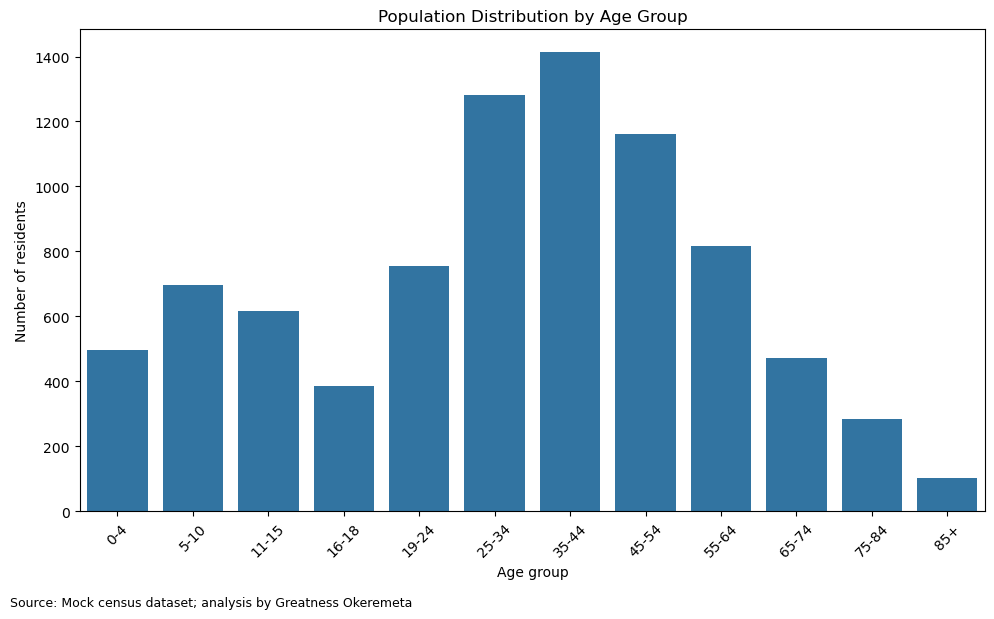

In [21]:
# Plot the population distribution by age group
plt.figure(figsize=(10, 6))
sns.barplot(data=age_distribution, x="age_group", y="population")
plt.title("Population Distribution by Age Group")
plt.xlabel("Age group")
plt.ylabel("Number of residents")
plt.xticks(rotation=45)
add_source_caption()
save_current_figure("population_distribution_by_age_group.png")
plt.show()

Saved figure!


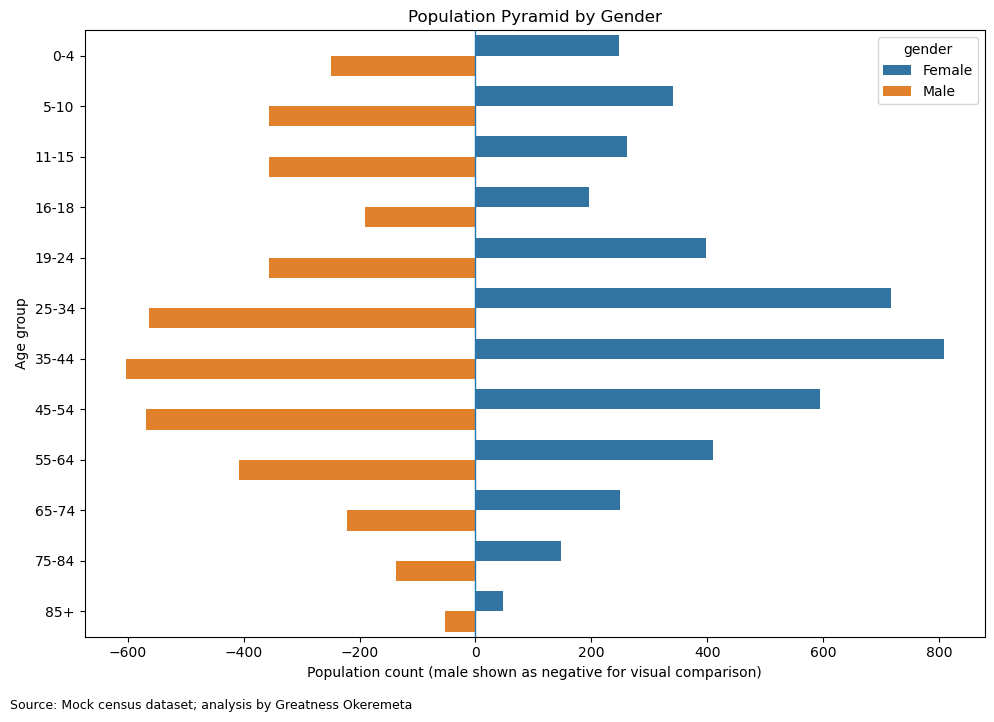

In [22]:
# Plot population pyramid by gender
pyramid = cleaned_df.groupby(["age_group", "gender"]).size().reset_index(name="count")
pyramid["plot_count"] = np.where(pyramid["gender"].str.lower().eq("male"), -pyramid["count"], pyramid["count"])

plt.figure(figsize=(10, 7))
sns.barplot(data=pyramid, y="age_group", x="plot_count", hue="gender", orient="h")
plt.title("Population Pyramid by Gender")
plt.xlabel("Population count (male shown as negative for visual comparison)")
plt.ylabel("Age group")
plt.axvline(0, linewidth=1)
add_source_caption()
save_current_figure("population_pyramid_by_gender.png")
plt.show()

## Household Occupancy and Housing Pressure

Household size is used to assess whether housing supply appears pressured, under-used or oriented toward larger households.

In [23]:
household_df = (
    cleaned_df.groupby("household_id")
    .agg(
        street=("street", "first"),
        house_number=("house_number", "first"),
        household_size=("household_id", "size"),
        children=("is_child", "sum"),
        working_age=("is_working_age", "sum"),
        retirement_age=("is_retirement_age", "sum"),
        professional_members=("is_professional_proxy", "sum")).reset_index())

household_df["occupancy_band"] = pd.cut(
    household_df["household_size"],
    bins=[0, 1, 2, 4, np.inf],
    labels=["Single-person", "Two-person", "Medium household", "Large household"])

household_summary = (
    household_df["occupancy_band"]
    .value_counts()
    .sort_index()
    .rename_axis("occupancy_band")
    .reset_index(name="households"))

household_summary["share_pct"] = (household_summary["households"] / len(household_df) * 100).round(2)
household_summary.to_csv(TABLES_DIR / "household_occupancy_summary.csv", index=False)
household_summary

,occupancy_band,households,share_pct
0,Single-person,575,20.39
1,Two-person,729,25.85
2,Medium household,1020,36.17
3,Large household,496,17.59


Saved figure!


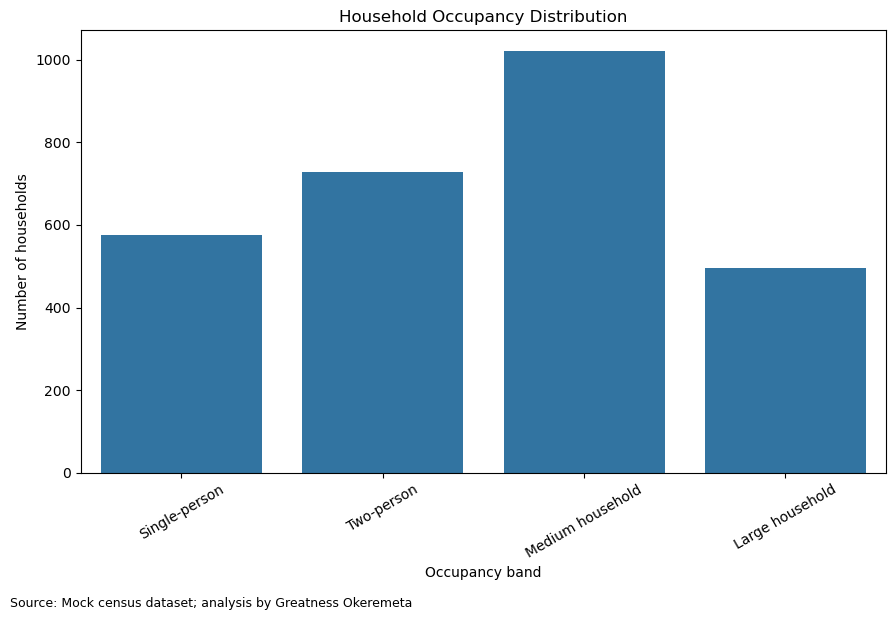

In [24]:
# plot the household occupancy distribution
plt.figure(figsize=(9, 6))
sns.barplot(data=household_summary, x="occupancy_band", y="households")
plt.title("Household Occupancy Distribution")
plt.xlabel("Occupancy band")
plt.ylabel("Number of households")
plt.xticks(rotation=30)
add_source_caption()
save_current_figure("household_occupancy_distribution.png")
plt.show()

## Employment and Training Analysis

This section estimates working-age unemployment and examines whether unemployment is concentrated in specific age bands. This directly informs the investment decision on employment and training.

In [25]:
working_age_df = cleaned_df[cleaned_df["is_working_age"]].copy()

unemployment_by_age = (
    working_age_df.groupby("age_group")
    .agg(
        working_age_population=("age", "size"),
        unemployed=("is_unemployed", "sum")).reset_index())

unemployment_by_age["unemployment_rate_pct"] = (
    unemployment_by_age["unemployed"] / unemployment_by_age["working_age_population"] * 100).round(2)

unemployment_by_age.to_csv(TABLES_DIR / "unemployment_by_age_group.csv", index=False)
unemployment_by_age

,age_group,working_age_population,unemployed,unemployment_rate_pct
0,0-4,0,0,NaN
1,5-10,0,0,NaN
2,11-15,0,0,NaN
3,16-18,386,1,0.26
4,19-24,755,25,3.31
5,25-34,1281,127,9.91
6,35-44,1413,168,11.89
7,45-54,1162,126,10.84
8,55-64,818,66,8.07
9,65-74,0,0,NaN


Saved figure!


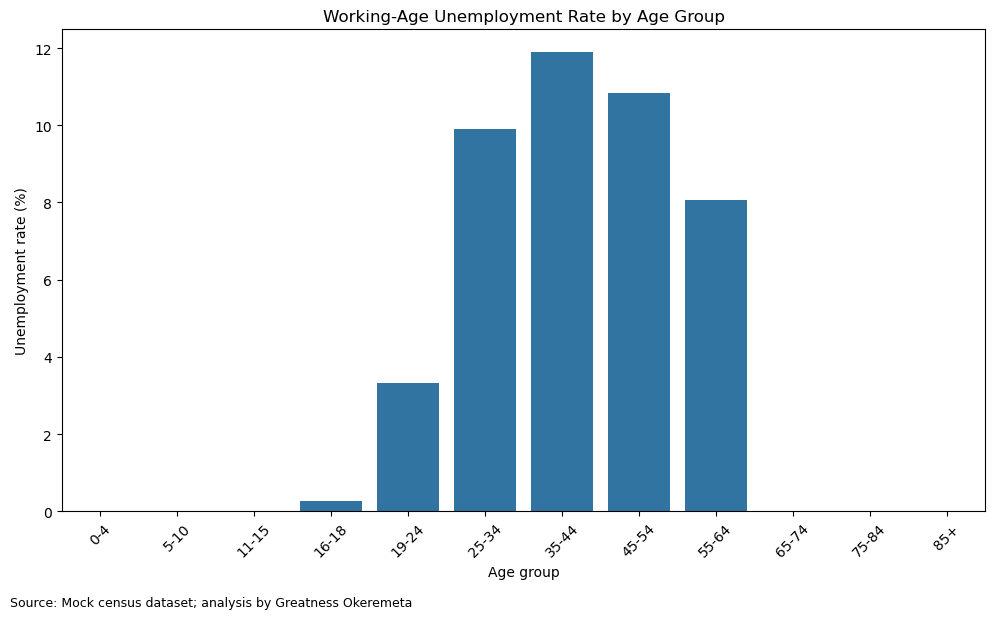

In [26]:
# plot the working-age unemployment rate by age group
plt.figure(figsize=(10, 6))
sns.barplot(data=unemployment_by_age, x="age_group", y="unemployment_rate_pct")
plt.title("Working-Age Unemployment Rate by Age Group")
plt.xlabel("Age group")
plt.ylabel("Unemployment rate (%)")
plt.xticks(rotation=45)
add_source_caption()
save_current_figure("unemployment_rate_by_age_group.png")
plt.show()

To assess whether unemployment varies meaningfully across different working-age groups, a Chi-square test of independence was performed. The test compares age group against unemployment status to determine whether the observed differences in unemployment are likely to be random or whether age group appears to be associated with employment outcomes in the census dataset.

In [27]:
if SCIPY_AVAILABLE:
    unemployment_table = pd.crosstab(working_age_df["age_group"], working_age_df["is_unemployed"])
    chi2, p_value, dof, expected = chi2_contingency(unemployment_table)

    unemployment_test_result = pd.DataFrame([{
        "test": "Chi-square test of independence",
        "hypothesis": "Unemployment status is independent of age group among working-age residents",
        "chi2_statistic": round(chi2, 4),
        "degrees_of_freedom": int(dof),
        "p_value": round(p_value, 6),
        "interpretation": "Reject independence; unemployment differs by age group" if p_value < 0.05 
        else "Insufficient evidence that unemployment differs by age group"}])
else:
    unemployment_test_result = pd.DataFrame([{
        "test": "Chi-square test of independence",
        "hypothesis": "Unemployment status is independent of age group among working-age residents",
        "chi2_statistic": np.nan,
        "degrees_of_freedom": np.nan,
        "p_value": np.nan,
        "interpretation": "SciPy not installed. Install scipy to run the statistical test."}])

# save the result to a csv file
unemployment_test_result.to_csv(TABLES_DIR / "unemployment_chi_square_test.csv", index=False)
unemployment_test_result

,test,hypothesis,chi2_statistic,degrees_of_freedom,p_value,interpretation
0,Chi-square test of independence,Unemployment status is independent of age grou...,88.6005,5,0.0,Reject independence; unemployment differs by a...


The Chi-square test of independence shows a statistically significant relationship between age group and unemployment status among working-age residents, χ²(5) = 88.6005, p < 0.001. This means unemployment is not evenly distributed across age groups in the dataset. Instead, some working-age groups appear to experience unemployment at different rates, suggesting that age may be an important demographic factor when assessing employment-related policy needs.

## Commuter Proxy and Transport Demand

The project brief states that university students commute because there is no university in the town. This analysis also adds a conservative proxy for likely commuter occupations to assess whether a train station could reduce road pressure.

In [28]:
commuter_summary = pd.DataFrame([
    {
        "metric": "University students",
        "count": int(cleaned_df["is_university_student"].sum()),
        "share_pct": safe_pct(cleaned_df["is_university_student"].sum(), len(cleaned_df))
    },
    {
        "metric": "All students",
        "count": int(cleaned_df["is_student"].sum()),
        "share_pct": safe_pct(cleaned_df["is_student"].sum(), len(cleaned_df))
    },
    {
        "metric": "Commuter proxy population",
        "count": int(cleaned_df["is_commuter_proxy"].sum()),
        "share_pct": safe_pct(cleaned_df["is_commuter_proxy"].sum(), len(cleaned_df))
    }])

# save the result to a csv file
commuter_summary.to_csv(TABLES_DIR / "commuter_summary.csv", index=False)
commuter_summary

,metric,count,share_pct
0,University students,542,6.39
1,All students,2226,26.23
2,Commuter proxy population,2128,25.08


Saved figure!


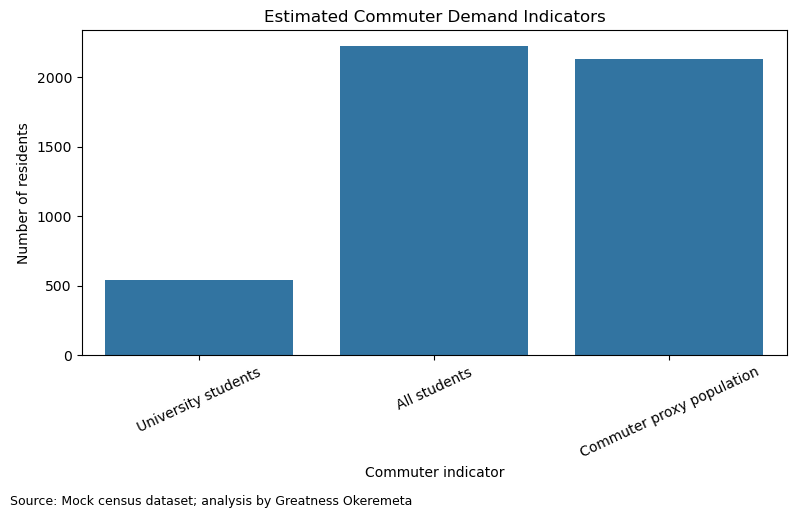

In [29]:
# plot the estimated commuter demand indicators
plt.figure(figsize=(8, 5))
sns.barplot(data=commuter_summary, x="metric", y="count")
plt.title("Estimated Commuter Demand Indicators")
plt.xlabel("Commuter indicator")
plt.ylabel("Number of residents")
plt.xticks(rotation=25)
add_source_caption()
save_current_figure("commuter_demand_indicators.png")
plt.show()

## Religious Affiliation Analysis

Religious affiliation is analysed to assess whether a second religious building is justified (the town already has one). Missing religion is treated as `Not stated` rather than imputed.

In [30]:
religion_summary = (
    cleaned_df["religion"]
    .value_counts()
    .rename_axis("religion")
    .reset_index(name="residents"))

religion_summary["share_pct"] = (religion_summary["residents"] / len(cleaned_df) * 100).round(2)
religion_summary.to_csv(TABLES_DIR / "religion_summary.csv", index=False)
religion_summary

,religion,residents,share_pct
0,Not stated,4847,57.12
1,Christian,1947,22.95
2,Catholic,925,10.90
3,Methodist,525,6.19
4,Muslim,153,1.80
5,Sikh,42,0.49
6,Jewish,35,0.41
7,Buddist,3,0.04
8,Nope,2,0.02
9,Pagan,2,0.02


Saved figure!


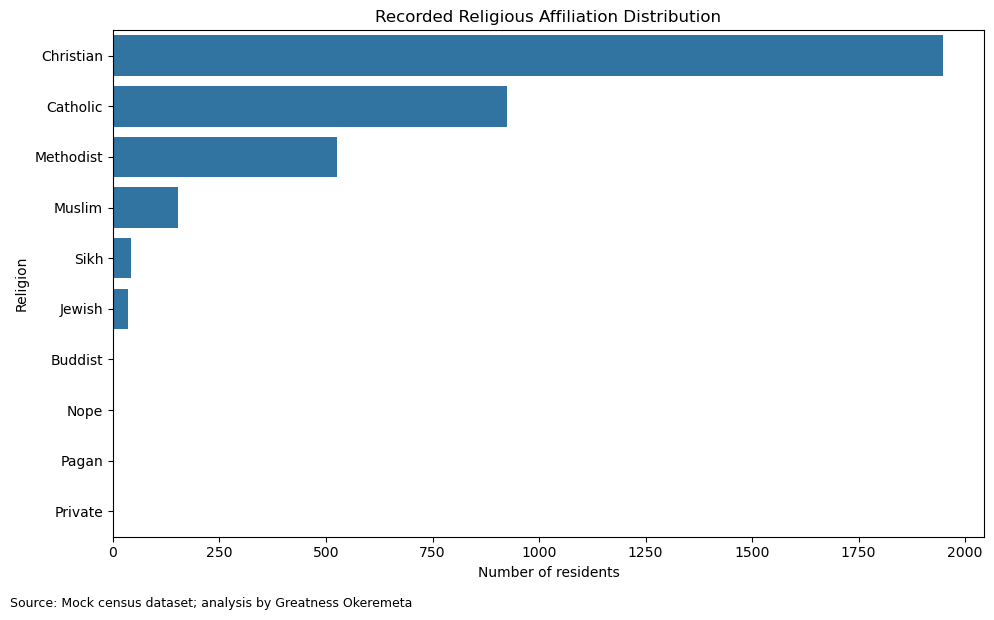

In [31]:
religion_plot_df = religion_summary[religion_summary["religion"] != "Not stated"].head(10)

# plot the town's religious affiliation 
plt.figure(figsize=(10, 6))
sns.barplot(data=religion_plot_df, y="religion", x="residents")
plt.title("Recorded Religious Affiliation Distribution")
plt.xlabel("Number of residents")
plt.ylabel("Religion")
add_source_caption()
save_current_figure("religious_affiliation_distribution.png")
plt.show()

## Marriage, Divorce and Housing Demand Proxy

Marital status can provide partial evidence for household formation, family housing demand and changing housing needs.

In [32]:
adult_df = cleaned_df[cleaned_df["age"] >= 16].copy()
marital_summary = (
    adult_df["marital_status"]
    .value_counts()
    .rename_axis("marital_status")
    .reset_index(name="adults"))

marital_summary["share_pct"] = (marital_summary["adults"] / len(adult_df) * 100).round(2)
marital_summary.to_csv(TABLES_DIR / "marital_status_summary.csv", index=False)
marital_summary

,marital_status,adults,share_pct
0,Single,2986,44.75
1,Married,2364,35.43
2,Divorced,762,11.42
3,Widowed,308,4.62
4,Unknown,252,3.78


Saved figure!


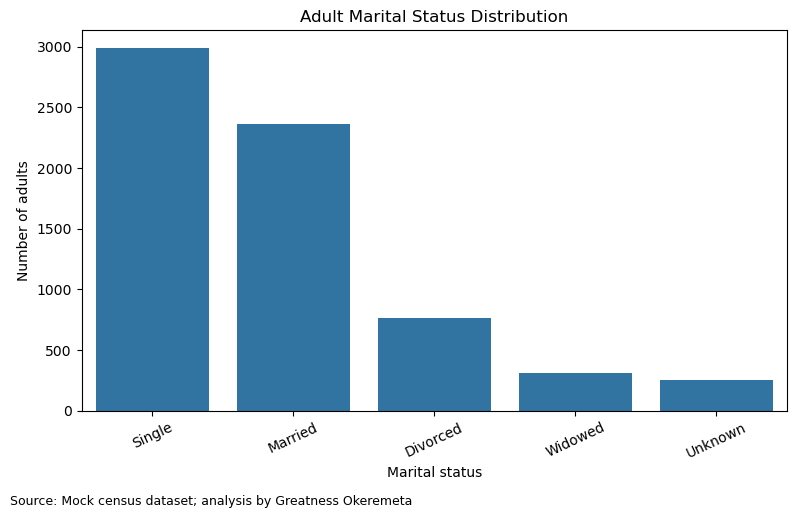

In [33]:
# plot the adult marital status distribution
plt.figure(figsize=(8, 5))
sns.barplot(data=marital_summary, x="marital_status", y="adults")
plt.title("Adult Marital Status Distribution")
plt.xlabel("Marital status")
plt.ylabel("Number of adults")
plt.xticks(rotation=25)
add_source_caption()
save_current_figure("adult_marital_status_distribution.png")
plt.show()

## Schooling and Ageing Pressure

This section evaluates the pressure for school investment and old-age care using age-based indicators.

In [34]:
service_pressure = pd.DataFrame([
    {
        "service_area": "Schooling",
        "indicator": "School-age residents aged 5-18",
        "count": int(cleaned_df["is_school_age"].sum()),
        "share_pct": safe_pct(cleaned_df["is_school_age"].sum(), len(cleaned_df))
    },
    {
        "service_area": "Future schooling pipeline",
        "indicator": "Children aged 0-4",
        "count": int(cleaned_df["is_under_5"].sum()),
        "share_pct": safe_pct(cleaned_df["is_under_5"].sum(), len(cleaned_df))
    },
    {
        "service_area": "Old age care",
        "indicator": "Residents aged 65+",
        "count": int(cleaned_df["is_retirement_age"].sum()),
        "share_pct": safe_pct(cleaned_df["is_retirement_age"].sum(), len(cleaned_df))
    },
    {
        "service_area": "Higher-intensity old age care",
        "indicator": "Residents aged 80+",
        "count": int(cleaned_df["is_older_elderly"].sum()),
        "share_pct": safe_pct(cleaned_df["is_older_elderly"].sum(), len(cleaned_df))
    },
    {
        "service_area": "Medical demand proxy",
        "indicator": "Residents with recorded infirmity",
        "count": int((~cleaned_df["infirmity"].eq("None recorded")).sum()),
        "share_pct": safe_pct((~cleaned_df["infirmity"].eq("None recorded")).sum(), len(cleaned_df))
    }])

service_pressure.to_csv(TABLES_DIR / "service_pressure_indicators.csv", index=False)
service_pressure

,service_area,indicator,count,share_pct
0,Schooling,School-age residents aged 5-18,1702,20.06
1,Future schooling pipeline,Children aged 0-4,497,5.86
2,Old age care,Residents aged 65+,857,10.10
3,Higher-intensity old age care,Residents aged 80+,230,2.71
4,Medical demand proxy,Residents with recorded infirmity,62,0.73


Saved figure!


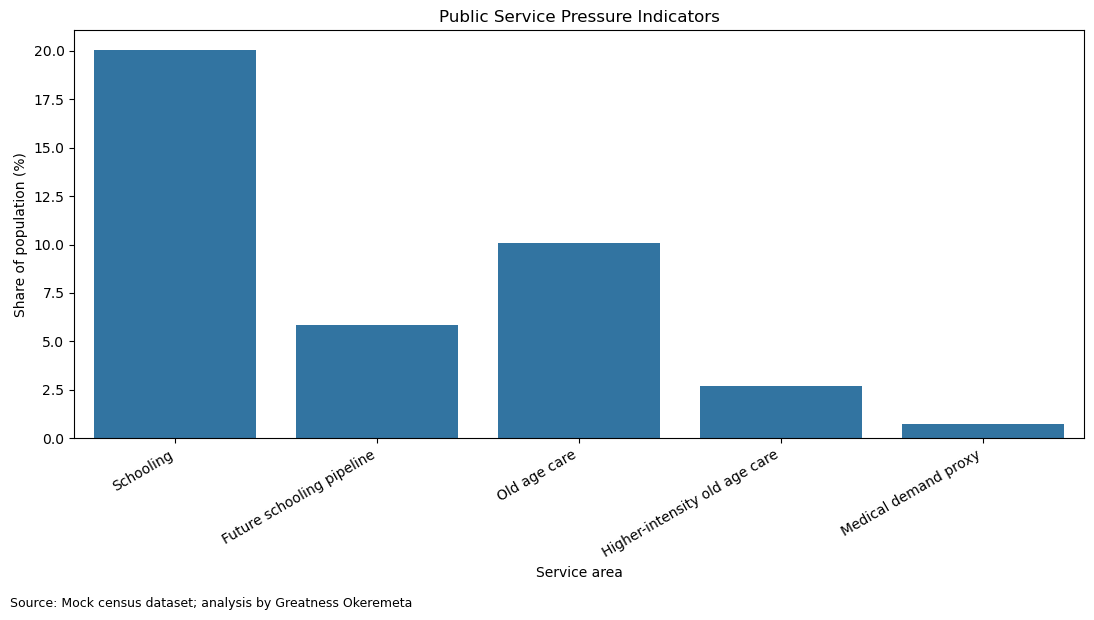

In [35]:
# plot the public service pressure indicators
plt.figure(figsize=(11, 6))
sns.barplot(data=service_pressure, x="service_area", y="share_pct")
plt.title("Public Service Pressure Indicators")
plt.xlabel("Service area")
plt.ylabel("Share of population (%)")
plt.xticks(rotation=30, ha="right")
add_source_caption()
save_current_figure("public_service_pressure_indicators.png")
plt.show()

### Headline findings

The town has a strong working-age population, a notable student presence and measurable unemployment among working-age residents. Household composition suggests demand for accessible housing, while high missingness in religion and limited health-service variables mean religious and medical infrastructure recommendations should be treated cautiously.

## Decision Matrix

The final decision is based on a transparent scoring matrix. The scores are not a replacement for real cost-benefit analysis, but they convert the evidence into a clear, explainable recommendation.

Score interpretation:
- **0.00 - 0.39:** weak evidence
- **0.40 - 0.69:** moderate evidence
- **0.70 - 1.00:** strong evidence

### Important note on scoring

The scoring matrix uses proxy indicators from the census data. Some options are supported by direct demographic evidence, such as age, employment status and household size. Other options rely on weaker proxies.

Religion is treated with particular caution because more than half of the population did not state a religion. For that reason, religious-building demand is weighted by total population share and capped where missingness is high. This avoids overestimating demand from only the subset of residents who reported a religion.

In [36]:
def clamp01(value: float) -> float:
    """A function to clamp a score between 0 and 1."""
    return max(0.0, min(1.0, float(value)))

In [37]:
def build_decision_matrices(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    
    """Build explainable land-use and investment decision matrices."""
    
    total_population = len(df)
    total_households = df["household_id"].nunique()
    working_age_count = df["is_working_age"].sum()

    commuter_share = df["is_commuter_proxy"].mean()
    university_student_share = df["is_university_student"].mean()
    unemployment_rate = ((df["is_unemployed"] & df["is_working_age"]).sum() / working_age_count) if working_age_count else 0
    retirement_share = df["is_retirement_age"].mean()
    older_elderly_share = df["is_older_elderly"].mean()
    school_age_share = df["is_school_age"].mean()
    under5_share = df["is_under_5"].mean()
    professional_share = df["is_professional_proxy"].mean()
    recorded_infirmity_share = (~df["infirmity"].eq("None recorded")).mean()

    household_level = df.drop_duplicates("household_id")
    large_household_share = household_level["occupancy_band"].eq("Large household").mean()
    single_two_person_share = household_level["occupancy_band"].isin(["Single-person", "Two-person"]).mean()

    # Religion evidence should be population-weighted and confidence-adjusted.
    religion_known = df[df["religion"] != "Not stated"]
    stated_religion_share = len(religion_known) / total_population if total_population else 0
    not_stated_religion_share = 1 - stated_religion_share
    
    top_non_catholic = "None"
    top_non_catholic_total_share = 0
    top_non_catholic_stated_share = 0
    
    if not religion_known.empty:
        non_catholic = religion_known[~religion_known["religion"].str.lower().eq("catholic")]
    
        if not non_catholic.empty:
            top_non_catholic = non_catholic["religion"].value_counts().idxmax()
            top_non_catholic_count = non_catholic["religion"].value_counts().iloc[0]
    
            # Share of the entire town, not just the stated-religion subset
            top_non_catholic_total_share = top_non_catholic_count / total_population
    
            # Share among people who stated a non-Catholic religion
            top_non_catholic_stated_share = top_non_catholic_count / len(non_catholic)
    
    religious_building_score = clamp01(
        (top_non_catholic_total_share / 0.30) * 0.70
        + (stated_religion_share / 0.70) * 0.30)

    # Conservative cap: if more than half the town did not state religion,
    # the evidence is not strong enough to make this the top land-use recommendation.
    if not_stated_religion_share > 0.50:
        religious_building_score = min(religious_building_score, 0.55)

    # Thresholds are intentionally documented and conservative.
    land_use = pd.DataFrame([
        {
            "option": "Train station",
            "score": round(clamp01((commuter_share / 0.25) * 0.7 + (university_student_share / 0.08) * 0.3), 3),
            "evidence_for": "High commuter proxy and confirmed university-student commuting pressure",
            "evidence_against": "No direct journey-to-work or traffic-volume field",
            "main_metric": f"Commuter proxy share: {commuter_share:.1%}; university student share: {university_student_share:.1%}",
        },
        {
            "option": "High-density housing",
            "score": round(clamp01((large_household_share / 0.30) * 0.5 + ((under5_share + school_age_share) / 0.35) * 0.5), 3),
            "evidence_for": "Large households and younger population imply potential housing pressure",
            "evidence_against": "No historical population growth or waiting-list data",
            "main_metric": f"Large household share: {large_household_share:.1%}; under-19 share: {(under5_share + school_age_share):.1%}",
        },
        {
            "option": "Low-density housing",
            "score": round(clamp01((professional_share / 0.25) * 0.6 + (large_household_share / 0.25) * 0.4), 3),
            "evidence_for": "Professional occupation proxy and larger households may support family housing",
            "evidence_against": "Income, property values and affordability are unavailable",
            "main_metric": f"Professional proxy share: {professional_share:.1%}; large household share: {large_household_share:.1%}",
        },
        {
            "option": "Religious building",
            "score": round(religious_building_score, 3),
            "evidence_for": f"Largest recorded non-Catholic group: {top_non_catholic}",
            "evidence_against": (
                "More than half of residents did not state a religion; no worship-capacity "
                "or unmet-demand data is available"),
            "main_metric": (f"{top_non_catholic} share of total population: {top_non_catholic_total_share:.1%}; "
                    f"religion not stated: {not_stated_religion_share:.1%}"),
        },
        {
            "option": "Emergency medical building",
            "score": round(clamp01((recorded_infirmity_share / 0.08) * 0.35 + (retirement_share / 0.20) * 0.35 + (under5_share / 0.08) * 0.30), 3),
            "evidence_for": "Older residents, infirmity records and young-child population create medical demand",
            "evidence_against": "No hospital admissions, GP waiting-time or accident data",
            "main_metric": f"Recorded infirmity: {recorded_infirmity_share:.1%}; 65+: {retirement_share:.1%}; under-5: {under5_share:.1%}",
        }]).sort_values("score", ascending=False)

    investment = pd.DataFrame([
        {
            "option": "Employment and training",
            "score": round(clamp01(unemployment_rate / 0.10), 3),
            "evidence_for": "Working-age unemployment creates direct need for skills and retraining",
            "evidence_against": "Occupation data does not show duration of unemployment or skills gaps",
            "main_metric": f"Working-age unemployment rate: {unemployment_rate:.1%}",
        },
        {
            "option": "Old age care",
            "score": round(clamp01((retirement_share / 0.20) * 0.7 + (older_elderly_share / 0.08) * 0.3), 3),
            "evidence_for": "65+ and 80+ shares indicate future care demand",
            "evidence_against": "No direct care-needs assessment or mortality history",
            "main_metric": f"65+ share: {retirement_share:.1%}; 80+ share: {older_elderly_share:.1%}",
        },
        {
            "option": "Increase spending for schooling",
            "score": round(clamp01((school_age_share / 0.22) * 0.65 + (under5_share / 0.08) * 0.35), 3),
            "evidence_for": "School-age and under-five population indicate current and near-future schooling demand",
            "evidence_against": "No school capacity, class-size or catchment-area data",
            "main_metric": f"School-age share: {school_age_share:.1%}; under-5 share: {under5_share:.1%}",
        },
        {
            "option": "General infrastructure",
            "score": round(clamp01((commuter_share / 0.25) * 0.35 + (large_household_share / 0.30) * 0.35 + ((school_age_share + under5_share) / 0.35) * 0.30), 3),
            "evidence_for": "Commuting, larger households and younger residents imply pressure on roads and services",
            "evidence_against": "No historical service-capacity or maintenance-cost data",
            "main_metric": f"Commuter share: {commuter_share:.1%}; large households: {large_household_share:.1%}; under-19: {(school_age_share + under5_share):.1%}",
        }]).sort_values("score", ascending=False)

    return land_use, investment

In [38]:
land_use_matrix, investment_matrix = build_decision_matrices(cleaned_df)
land_use_matrix.to_csv(TABLES_DIR / "land_use_decision_matrix.csv", index=False)
investment_matrix.to_csv(TABLES_DIR / "investment_decision_matrix.csv", index=False)

land_use_matrix

,option,score,evidence_for,evidence_against,main_metric
0,Train station,0.942,High commuter proxy and confirmed university-s...,No direct journey-to-work or traffic-volume field,Commuter proxy share: 25.1%; university studen...
2,Low-density housing,0.787,Professional occupation proxy and larger house...,"Income, property values and affordability are ...",Professional proxy share: 21.1%; large househo...
1,High-density housing,0.663,Large households and younger population imply ...,No historical population growth or waiting-lis...,Large household share: 17.6%; under-19 share: ...
3,Religious building,0.550,Largest recorded non-Catholic group: Christian,More than half of residents did not state a re...,Christian share of total population: 22.9%; re...
4,Emergency medical building,0.428,"Older residents, infirmity records and young-c...","No hospital admissions, GP waiting-time or acc...",Recorded infirmity: 0.7%; 65+: 10.1%; under-5:...


Saved figure!


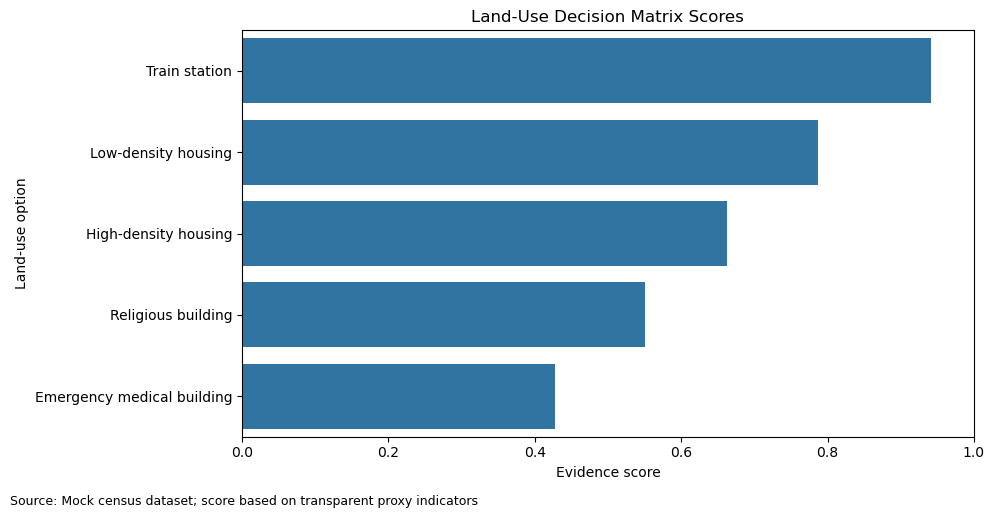

In [39]:
# plot the land-use decision matrix scores
plt.figure(figsize=(10, 5))
sns.barplot(data=land_use_matrix, y="option", x="score")
plt.title("Land-Use Decision Matrix Scores")
plt.xlabel("Evidence score")
plt.ylabel("Land-use option")
plt.xlim(0, 1)
add_source_caption("Source: Mock census dataset; score based on transparent proxy indicators")
save_current_figure("land_use_decision_matrix_scores.png")
plt.show()

### Summary of religious affiliation evidence

Religious affiliation alone does not provide strong enough evidence to prioritise a new religious building. Although Christian groups form the largest share among residents who stated a religion, more than half of the town did not report religious affiliation. This high missingness means the analysis should not infer broad demand for a new place of worship without additional evidence such as worship attendance, facility capacity, community consultation or distance to existing religious buildings.

Therefore, religion is included in the decision matrix, but with a conservative score adjustment.

Saved figure!


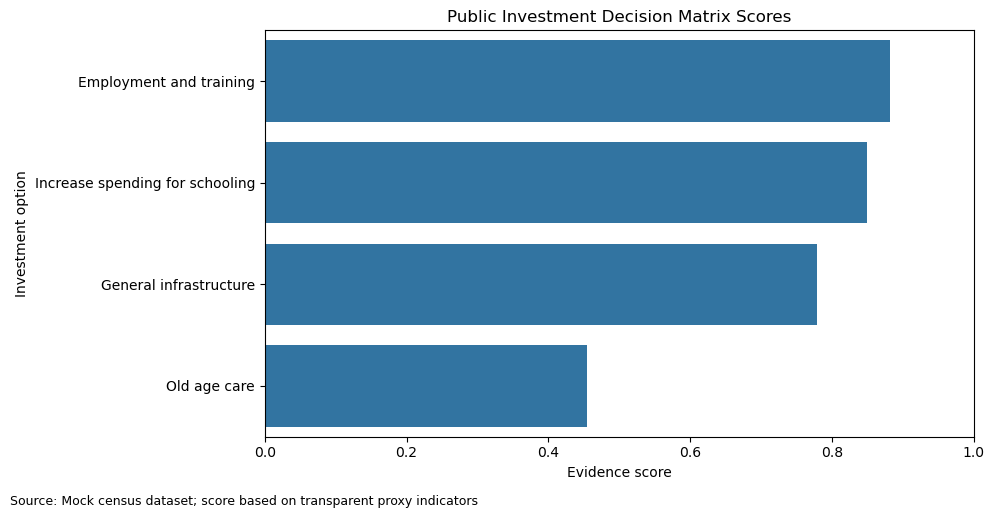

In [40]:
# plot the public investment decision matrix scores
plt.figure(figsize=(10, 5))
sns.barplot(data=investment_matrix, y="option", x="score")
plt.title("Public Investment Decision Matrix Scores")
plt.xlabel("Evidence score")
plt.ylabel("Investment option")
plt.xlim(0, 1)
add_source_caption("Source: Mock census dataset; score based on transparent proxy indicators")
save_current_figure("investment_decision_matrix_scores.png")
plt.show()

## Final Recommendation

The recommendations below are generated from the evidence matrix. They should be read as a data-driven planning recommendation, not a final real-world planning approval, because cost, land availability, public consultation, environmental impact and statutory planning constraints are outside the dataset.

In [41]:
top_land_use = land_use_matrix.iloc[0]
top_investment = investment_matrix.iloc[0]

recommendation_summary = pd.DataFrame([
    {
        "decision_area": "Land use",
        "recommended_option": top_land_use["option"],
        "evidence_score": top_land_use["score"],
        "main_metric": top_land_use["main_metric"],
        "evidence_for": top_land_use["evidence_for"],
        "evidence_against": top_land_use["evidence_against"],
    },
    {
        "decision_area": "Public investment",
        "recommended_option": top_investment["option"],
        "evidence_score": top_investment["score"],
        "main_metric": top_investment["main_metric"],
        "evidence_for": top_investment["evidence_for"],
        "evidence_against": top_investment["evidence_against"],
    }])

recommendation_summary.to_csv(REPORTS_DIR / "recommendation_summary.csv", index=False)
recommendation_summary

,decision_area,recommended_option,evidence_score,main_metric,evidence_for,evidence_against
0,Land use,Train station,0.942,Commuter proxy share: 25.1%; university studen...,High commuter proxy and confirmed university-s...,No direct journey-to-work or traffic-volume field
1,Public investment,Employment and training,0.882,Working-age unemployment rate: 8.8%,Working-age unemployment creates direct need f...,Occupation data does not show duration of unem...


### Recommendation logic

The final recommendation is not based only on the highest raw score. It also considers the quality of the evidence behind each score. Options supported by direct demographic indicators are treated as stronger than options based on highly incomplete or indirect proxy fields.

In [42]:
print("FINAL POLICY RECOMMENDATION")
print()
print(f"1. Recommended land use: {top_land_use['option']} (score: {top_land_use['score']})")
print(f"   Main evidence: {top_land_use['main_metric']}")
print(f"   Rationale: {top_land_use['evidence_for']}")
print()
print(f"2. Recommended investment priority: {top_investment['option']} (score: {top_investment['score']})")
print(f"   Main evidence: {top_investment['main_metric']}")
print(f"   Rationale: {top_investment['evidence_for']}")
print()
print("Important caveat: these recommendations are based on census-derived proxy indicators.\n "
      "Options affected by high missingness, especially religion, should be validated with\n "
      "community consultation and service-capacity data before implementation.")

FINAL POLICY RECOMMENDATION

1. Recommended land use: Train station (score: 0.942)
   Main evidence: Commuter proxy share: 25.1%; university student share: 6.4%
   Rationale: High commuter proxy and confirmed university-student commuting pressure

2. Recommended investment priority: Employment and training (score: 0.882)
   Main evidence: Working-age unemployment rate: 8.8%
   Rationale: Working-age unemployment creates direct need for skills and retraining

Important caveat: these recommendations are based on census-derived proxy indicators.
 Options affected by high missingness, especially religion, should be validated with
 community consultation and service-capacity data before implementation.


_The End_